problema inverso para oscilador harmonico

In [1]:
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from functools import partial

In [2]:
class PINN(nn.Module):
    '''
    Parâmetros:

    - malha_interna:     pontos internos da malha (colocation points), usados para
                         calcular o resíduo da equação diferencial;
    - u_interno:         dados experimentais na malha_interna;
    - malha_inicial:     pontos iniciais da malha, definem valores iniciaisde u(t);
    - u_inicial:         valores de u(t=0) nos pontos da malha interna (condição inicial);
    - malha_contorno:    pontos que definem o contorno da malha;
    - u_contorno:        valores de u nos pontos de contorno (condição de contorno);
    - peso_ed:           peso que pondera a loss da equação diferencial na loss total;
    - func_campo:        tensor com os valores de f(u, t) nos pontos internos,
                         que define a equação diferencial  du/dt = f(u, t);
    - camadas_ocultas:   lista com o número de neurônios em cada camada oculta,
                         ex: [32, 32, 32];
    - num_dados_entrada: número de variáveis de entrada da rede, ex: 1 para só t,
                         2 para t e x, etc.;
    - funcao_ativacao:   instância da função de ativação, ex: nn.Tanh();
    - params_ed:         dicionário de strings representando parâmetros da equação diferencial 
                         a serem incluídos como parâmetros da rede a fim de resolver 
                         o problema inverso relacionadas com um chute inicial para cada parâmetro
                         (padrão: None), ex: {'λ1':v1, 'λ2':v2, ...};
    - taxa_aprendizado:  taxa de aprendizado do otimizador (padrão: 1e-3).
    '''

    def __init__(
        self,
        malha_interna,
        u_interno,
        malha_inicial,
        u_inicial,
        malha_contorno,
        u_contorno,
        func_campo,
        peso_ed,
        camadas_ocultas,
        num_dados_entrada,
        funcao_ativacao,
        params_ed=None,
        taxa_aprendizado=1e-3,
    ):
        super().__init__()

        # requires_grad=True na malha interna pois precisa de du/dt via autograd
        self.malha_interna    = torch.tensor(malha_interna,  dtype=torch.float32, requires_grad=True)
        self.u_interno        = torch.tensor(u_interno,      dtype=torch.float32)
        self.malha_inicial    = torch.tensor(malha_inicial,  dtype=torch.float32, requires_grad=True)
        self.u_inicial        = torch.tensor(u_inicial,      dtype=torch.float32)
        self.malha_contorno   = torch.tensor(malha_contorno, dtype=torch.float32, requires_grad=True)
        self.u_contorno       = torch.tensor(u_contorno,     dtype=torch.float32)
        self.func_campo       = func_campo
        self.peso_ed          = peso_ed
        self.taxa_aprendizado = taxa_aprendizado
        if params_ed is not None:
            self.params_ed    = nn.ParameterDict()
            for nome, valor_inicial in params_ed.items():
                self.params_ed[nome] = nn.Parameter(torch.tensor([valor_inicial]))

        
        arquitetura = []

        # Primeira camada oculta
        arquitetura.append(nn.Linear(num_dados_entrada, camadas_ocultas[0]))
        arquitetura.append(funcao_ativacao)

        # Demais camadas ocultas
        for i in range(1, len(camadas_ocultas)):
            arquitetura.append(nn.Linear(camadas_ocultas[i - 1], camadas_ocultas[i]))
            arquitetura.append(funcao_ativacao)

        # Camada de saída (funções têm um único output -> num_targets = 1)
        # Sem função de ativação na saída
        arquitetura.append(nn.Linear(camadas_ocultas[-1], 1))

        self.camadas = nn.Sequential(*arquitetura)

    # Função auxiliar para função de perda
    def derivada(self, u, t, ordem=1):
        '''
        Calcula a derivada de u em relação a t de forma recursiva.

        Parâmetros:
        - u: tensor de saída da rede;
        - t: tensor de entrada (deve ter requires_grad=True);
        - ordem: ordem da derivada desejada.
        '''
        du = u
        for _ in range(ordem):
            du = torch.autograd.grad(
                outputs=du,
                inputs=t,
                grad_outputs=torch.ones_like(du),
                create_graph=True,
                retain_graph=True,
            )[0]
        return du

    # ------------------------------ #
    #        Função de Perda         # -> onde a PINN é diferente 1.0
    # ------------------------------ #
    
    def fun_perda(self, u_contorno_pred, u_inicial_pred, u_interno_pred, ordem=1, periodica=False):
        '''
        Calcula a função de perda da PINN:

            L = loss_dados + peso_ed * loss_ed

        - loss_dados: erro quadrático médio nos pontos onde temos valores
        conhecidos (dados experimentais + condição inicial + condição de contorno);
        - loss_ed: erro quadrático médio dos resíduos da equação diferencial nos pontos internos, 
        calculado via diferenciação automática.
        - ordem: ordem da derivada na ED, definida como primeira ordem por padrão.

        Retorna: loss_total, loss_interna, loss_inicial, loss_contorno, loss_ed, loss_periodica
        '''

        # Loss dos dados
        loss_interna   = torch.mean((u_interno_pred - self.u_interno)**2)   # MSE de u_interno
        loss_inicial   = torch.mean((u_inicial_pred - self.u_inicial)**2)   # MSE de u_inicial
        loss_contorno  = torch.mean((u_contorno_pred - self.u_contorno)**2) # MSE de u_contorno
        loss_periodica = torch.tensor(0.0, dtype=torch.float32)
        if periodica: 
            for o in range(ordem):
                '''Calcula loss periódica para u, du/dt, ..., d^{ordem - 1}u/dt^{ordem - 1}'''

                # Calcula u, u', u'', ... inicial e contorno
                du_inicial  = self.derivada(u_inicial_pred,  self.malha_inicial, ordem=o)
                du_contorno = self.derivada(u_contorno_pred, self.malha_contorno, ordem=o)

                # Somatória loss_periodica
                residuo_periodo = du_contorno - du_inicial         # resíduo de extremos de um período
                loss_periodica += torch.mean((residuo_periodo)**2) # MSE de resíduo do período


        loss_dados = loss_interna + loss_inicial + loss_contorno + loss_periodica

        # Loss da Equação Diferencial (ed)
        du = self.derivada(u_interno_pred, self.malha_interna, ordem=ordem) # du/dt via diferenciação automática
        residuo_ed = du - self.func_campo(u_interno_pred, **self.params_ed) # Resíduo: du/dt - f(u, t) = 0
        loss_ed = torch.mean(residuo_ed**2)                                 # MSE de resíduo da Equação Diferencial

        # Loss total
        loss_total = loss_dados + self.peso_ed * loss_ed

        return loss_total, loss_interna, loss_inicial, loss_contorno, loss_ed, loss_periodica

    def forward(self, x):
        return self.camadas(x)

    # ------------------------------ #
    #          Treinamento           # -> onde a PINN é diferente 2.0
    # ------------------------------ #
    
    def treinar(self, num_epocas, verbose=True, intervalo_log=100, ordem=1, periodica=False):
        '''
        Executa o loop de treinamento da PINN.

        Parâmetros:
        - num_epocas:    número de épocas de treinamento;
        - verbose:       se True, imprime a perda a cada intervalo_log épocas;
        - intervalo_log: de quantas em quantas épocas imprimir o histórico (log);
        - ordem:         ordem da derivada na ED, definida como primeira ordem por padrão.
        - periodica:     se True, indica que deve usar loss_periodica;
                         
        Retorna: histórico com as perdas por época.
        '''

        # Instancia L-BFGS
        otimizador = optim.LBFGS(self.parameters(), lr=self.taxa_aprendizado)

        # Instancia o dicionário de histórico
        historico = {
            'loss_total':     [],
            'loss_interna':   [],
            'loss_inicial':   [],
            'loss_contorno':  [],
            'loss_ed':        [],
            'loss_periodica': [],
        }

        # Função pedida pelo otimizador L-BFGS
        def closure():
            '''Função closure para step do L-BFGS, ela recalcula a loss total.'''

            # Zera gradiente
            otimizador.zero_grad()

            # Forward pass para CADA MALHA
            u_interno_pred  = self.forward(self.malha_interna)  # Previsão da malha interna
            u_inicial_pred  = self.forward(self.malha_inicial)  # Previsão da malha inicial
            u_contorno_pred = self.forward(self.malha_contorno) # Previsão da malha de contorno

            # Calcula Loss
            loss_total, _, _, _, _, _ = self.fun_perda(
                u_contorno_pred, u_inicial_pred, u_interno_pred, ordem=ordem, periodica=periodica)

            # Faz backpropagation da loss total
            loss_total.backward()
               
            return loss_total

        # Loop de treinamento
        for epoca in range(1, num_epocas + 1):

            # Forward pass para CADA MALHA
            u_interno_pred  = self.forward(self.malha_interna)  # Previsão da malha interna
            u_inicial_pred  = self.forward(self.malha_inicial)  # Previsão da malha inicial
            u_contorno_pred = self.forward(self.malha_contorno) # Previsão da malha de contorno

            # Calcula Loss
            loss_total, loss_interna, loss_inicial, loss_contorno, loss_ed, loss_periodica = self.fun_perda(
                u_contorno_pred, u_inicial_pred, u_interno_pred, ordem=ordem, periodica=periodica)

            # Atualiza parâmetros (zero grad e backprop embutidos)
            otimizador.step(closure)

            # Salva histórico
            historico['loss_total'].append(loss_total.item())
            historico['loss_interna'].append(loss_interna.item())
            historico['loss_inicial'].append(loss_inicial.item())
            historico['loss_contorno'].append(loss_contorno.item())
            historico['loss_ed'].append(loss_ed.item())
            historico['loss_periodica'].append(loss_periodica.item())

            # Mostra resultado (opcional através de verbose)
            if verbose and (epoca % intervalo_log == 0 or epoca == 1):
                if periodica:
                    print(
                        f"Época {epoca:>{len(str(num_epocas))}}/{num_epocas} | "
                        f"Loss: {loss_total.item():.2e} | "
                        f"Interna: {loss_interna.item():.2e} | "
                        f"Inicial: {loss_inicial.item():.2e} | "
                        f"Contorno: {loss_contorno.item():.2e} | "
                        f"Periódica: {loss_periodica.item(): .2e} | "
                        f"ED: {loss_ed.item():.2e}"
                    )
                else:
                    print(
                        f"Época {epoca:>{len(str(num_epocas))}}/{num_epocas} | "
                        f"Loss: {loss_total.item():.2e} | "
                        f"Interna: {loss_interna.item():.2e} | "
                        f"Inicial: {loss_inicial.item():.2e} | "
                        f"Contorno: {loss_contorno.item():.2e} | "
                        f"ED: {loss_ed.item():.2e}"
                    )

        return historico

## Testando a PINN

In [3]:
from funcoes import func_campo_ohs as func_campo
from funcoes import solucao_analitica_ohs as solucao_analitica
from funcoes import criar_malhas, plot_losses, plot_solucao, prever

In [4]:
# Parâmetros físicos
w0 = 2.0                   # Frequência de oscilação
x0 = 1.0                   # Posção inicial
v0 = x0*w0                 # Velocidade inicial
T_periodo = 2 * np.pi / w0 # Período da função
t_min, t_max = 0.0, 10.0   # Tempo em segundos (s)

# Parâmetro para descoberta
PARAMS_ED = {'w0': 1.5}

# Parâmetros computacionais
n_dados     = 40           # Número de pontos na malha interna, usada para treino
nivel_ruido = 0.02         # Desvio padrão do ruído gaussiano
random_seed = 9            # Semente aleatória
torch.manual_seed(random_seed)
np.random.seed(random_seed)

u_min, u_max = -x0 * np.sqrt(2), x0 * np.sqrt(2)     # Para normalização

# Para montar funções parciais
params_fc_campo      = {}
params_sol_analitica = {'x0': x0, 'w0': w0}

In [5]:
solucao_analitica_parcial = partial(solucao_analitica, **params_sol_analitica)
func_campo_parcial        = partial(func_campo, **params_fc_campo)

malha_interna, malha_inicial, malha_contorno, u_interno, u_inicial, u_contorno = criar_malhas(
    t_min=[t_min],
    t_max=[t_max],

    u0=[[x0, v0]],
    solucao_analitica=solucao_analitica_parcial,

    n_dados=n_dados,
    nivel_ruido=nivel_ruido,
    random_seed=random_seed,

    periodica=True,
    T_periodo=T_periodo,

    norm=True,
    u_min=u_min,
    u_max=u_max,
)

In [6]:
class Seno(nn.Module):
    def forward(self, x):
        return torch.sin(x)

PESO_ED = 1                 # Arbitrário
CAMADAS_OCULTAS = 4*[100]   # Arbitrário
FUNCAO_ATIVACAO = Seno()

num_dados_entrada = 1       # u(t) depende apenas de t

In [7]:
pinn = PINN(
        malha_interna=malha_interna,
        u_interno=u_interno,
        malha_inicial=malha_inicial,
        u_inicial=u_inicial,
        malha_contorno=malha_contorno,
        u_contorno=u_contorno,
        peso_ed=PESO_ED,
        func_campo=func_campo_parcial,
        camadas_ocultas=CAMADAS_OCULTAS,
        num_dados_entrada=num_dados_entrada,
        params_ed=PARAMS_ED,
        funcao_ativacao=FUNCAO_ATIVACAO)

In [8]:
NUM_EPOCAS = 500

historico = pinn.treinar(NUM_EPOCAS, ordem=2, periodica=True);

Época   1/500 | Loss: 1.77e+00 | Interna: 5.26e-01 | Inicial: 8.66e-01 | Contorno: 3.10e-01 | Periódica:  3.88e-03 | ED: 6.62e-02
Época 100/500 | Loss: 9.54e-01 | Interna: 7.02e-01 | Inicial: 1.81e-01 | Contorno: 1.39e-02 | Periódica:  5.56e-02 | ED: 1.35e-03
Época 200/500 | Loss: 9.54e-01 | Interna: 7.01e-01 | Inicial: 1.81e-01 | Contorno: 1.43e-02 | Periódica:  5.65e-02 | ED: 1.25e-03
Época 300/500 | Loss: 9.54e-01 | Interna: 7.01e-01 | Inicial: 1.81e-01 | Contorno: 1.43e-02 | Periódica:  5.65e-02 | ED: 1.27e-03
Época 400/500 | Loss: 9.54e-01 | Interna: 7.01e-01 | Inicial: 1.81e-01 | Contorno: 1.43e-02 | Periódica:  5.66e-02 | ED: 1.29e-03
Época 500/500 | Loss: 9.54e-01 | Interna: 7.01e-01 | Inicial: 1.81e-01 | Contorno: 1.43e-02 | Periódica:  5.66e-02 | ED: 1.30e-03


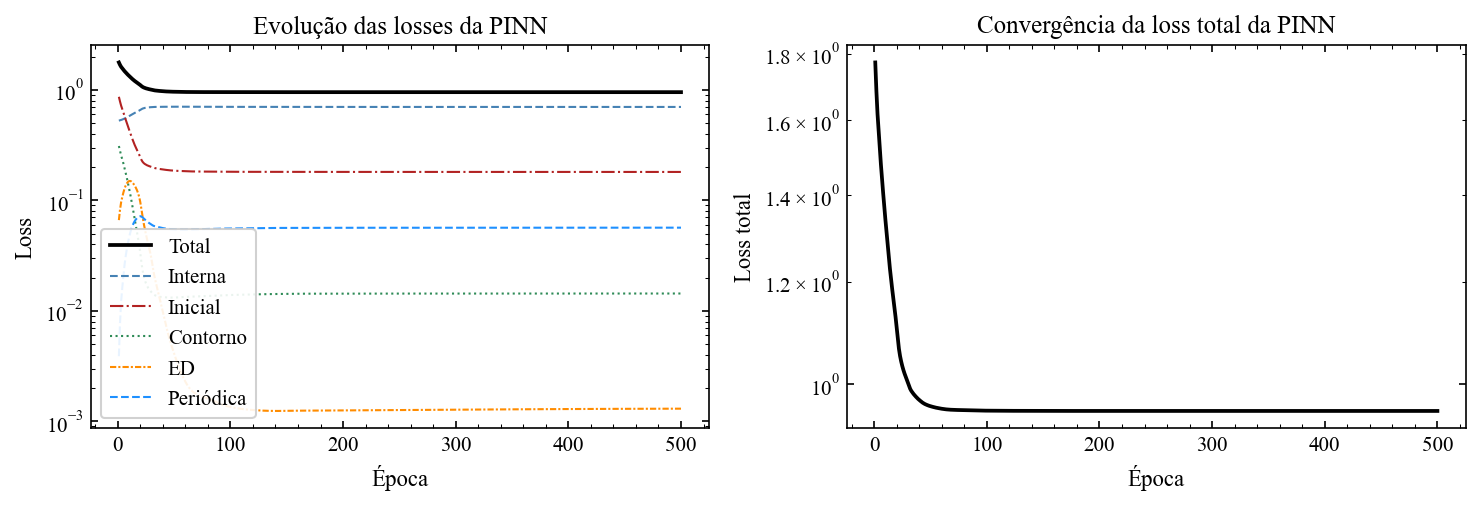

In [9]:
plot_losses(historico, nome_modelo='PINN', periodica=True)

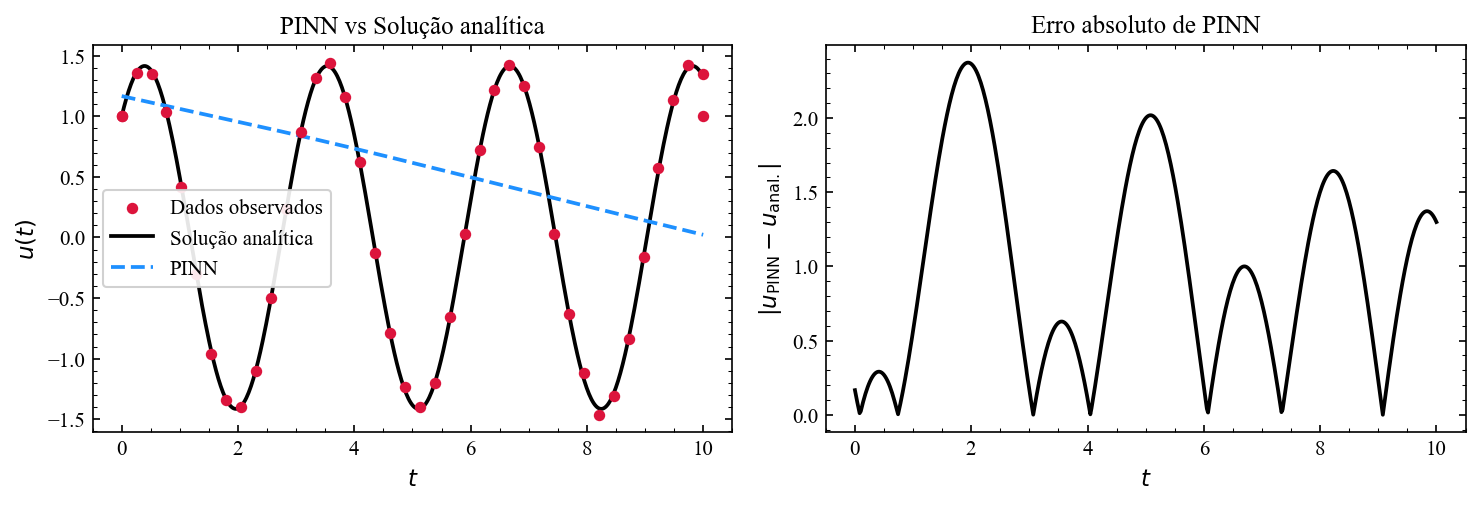

In [10]:
# Previsão
t_plot, u_pinn = prever(
    modelo=pinn,
    t_min=t_min, 
    t_max=t_max, 
    t_min_prev=t_min, 
    t_max_prev=t_max,
    norm=True,
    u_min=u_min,
    u_max=u_max,
)
    
# Plot PINN
plot_solucao(
    solucao_analitica=solucao_analitica_parcial,
    t_plot=t_plot,
    u_prev=u_pinn,
    malha_interna=malha_interna,
    u_interno=u_interno,
    u_inicial=u_inicial,
    u_contorno=u_contorno,
    t_min=t_min,
    t_max=t_max,
    nome_modelo='PINN',
    norm=True,
    u_min=u_min,
    u_max=u_max,
)

In [11]:
# Ver todos os parâmetros e seus valores
for nome, param in pinn.params_ed.items():
    print(f"{nome}_pred: {param.item():.4f}")

w0_pred: 0.2465
